<h1><center>Pixar Movie Analysis</center></h1>

In [9]:
#Import libraries
import os
import pandas as pd   
import matplotlib.pyplot as plt
import matplotlib.dates as dates  
from datetime import datetime
import numpy as np
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
pixar = pd.read_csv('/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Data Mining/data-mining/pixar_films new.csv')
pixar.head()

,ID,film,film_rating,cinema_score,release_date,run_time,budget,box_office_us_canada,box_office_other,box_office_worldwide,rotten_tomatoes_score,rotten_tomatoes_counts,metacritic_score,metacritic_counts,imdb_score,imdb_counts
0,1,Toy Story,G,A,11/22/1995,81,30000000,223225679,171210907,394436586,100,96,95,26,8.3,1089101
1,2,A Bug's Life,G,A,11/25/1998,95,120000000,162798565,200460294,363258859,92,91,78,23,7.2,319596
2,3,Toy Story 2,G,A+,11/24/1999,92,90000000,245852179,265506097,511358276,100,172,88,34,7.9,630573
3,4,"Monsters, Inc.",G,A+,11/2/2001,92,115000000,255873250,272900000,528773250,96,199,79,35,8.1,1000657
4,5,Finding Nemo,G,A+,5/30/2003,100,94000000,339714978,531300000,871014978,99,270,90,38,8.2,1132877


In [3]:
pixar.shape
print(f"The dataset contains {pixar.shape[0]} rows and {pixar.shape[1]} columns.")

The dataset contains 28 rows and 16 columns.


In [4]:
pixar.info()
print(f"The dataset contains {pixar.isnull().sum().sum()} missing values.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      28 non-null     int64  
 1   film                    28 non-null     object 
 2   film_rating             28 non-null     object 
 3   cinema_score            25 non-null     object 
 4   release_date            28 non-null     object 
 5   run_time                28 non-null     int64  
 6   budget                  28 non-null     int64  
 7   box_office_us_canada    28 non-null     int64  
 8   box_office_other        28 non-null     int64  
 9   box_office_worldwide    28 non-null     int64  
 10  rotten_tomatoes_score   28 non-null     int64  
 11  rotten_tomatoes_counts  28 non-null     int64  
 12  metacritic_score        28 non-null     int64  
 13  metacritic_counts       28 non-null     int64  
 14  imdb_score              28 non-null     floa

In [6]:
pixar.describe()

,ID,run_time,budget,box_office_us_canada,box_office_other,box_office_worldwide,rotten_tomatoes_score,rotten_tomatoes_counts,metacritic_score,metacritic_counts,imdb_score,imdb_counts
count,28.000000,28.000000,2.800000e+01,2.800000e+01,2.800000e+01,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01
mean,14.500000,100.392857,1.553929e+08,2.475444e+08,3.611199e+08,6.086643e+08,88.357143,273.821429,78.142857,43.464286,7.542857,5.256077e+05
std,8.225975,8.047725,5.382092e+07,1.631609e+08,2.300110e+08,3.826497e+08,13.447330,84.248773,12.408821,9.558716,0.658522,3.688713e+05
min,1.000000,81.000000,0.000000e+00,9.461540e+05,2.041436e+07,2.181336e+07,40.000000,91.000000,57.000000,23.000000,6.100000,1.270450e+05
25%,7.750000,95.000000,1.200000e+08,1.540453e+08,2.069555e+08,3.787627e+08,79.750000,220.000000,68.250000,37.000000,7.175000,1.955322e+05
50%,14.500000,100.000000,1.750000e+08,2.305457e+08,3.218588e+08,5.338782e+08,94.500000,266.000000,79.500000,41.000000,7.550000,3.958430e+05
75%,21.250000,104.250000,2.000000e+08,3.046819e+08,5.086871e+08,8.253837e+08,97.000000,324.000000,88.500000,52.000000,8.100000,8.385082e+05
max,28.000000,118.000000,2.000000e+08,6.529802e+08,1.045051e+09,1.698031e+09,100.000000,459.000000,96.000000,59.000000,8.400000,1.226415e+06


In [ ]:
# Prepare data for analysis
pixar_movies=pixar[['film', 'release_date']]
pixar_movies['release_date'] = pd.to_datetime(pixar_movies['release_date'])
pixar_movies['level']= [np.random.randint(-6, -2) if (i%2) == 0 else np.random.randint(2,6) for i in range(len(pixar_movies))]

In [12]:
# Display first and last 5 records.
print(pixar_movies.head(5))
print(pixar_movies.tail(5))

             film release_date  level
0       Toy Story   1995-11-22     -6
1    A Bug's Life   1998-11-25      2
2     Toy Story 2   1999-11-24     -6
3  Monsters, Inc.   2001-11-02      2
4    Finding Nemo   2003-05-30     -3
            film release_date  level
23          Luca   2021-06-18      5
24   Turning Red   2022-03-11     -4
25     Lightyear   2022-06-17      4
26     Elemental   2023-06-16     -4
27  Inside Out 2   2024-06-14      4


<h1><center>Visualizations</center></h1>

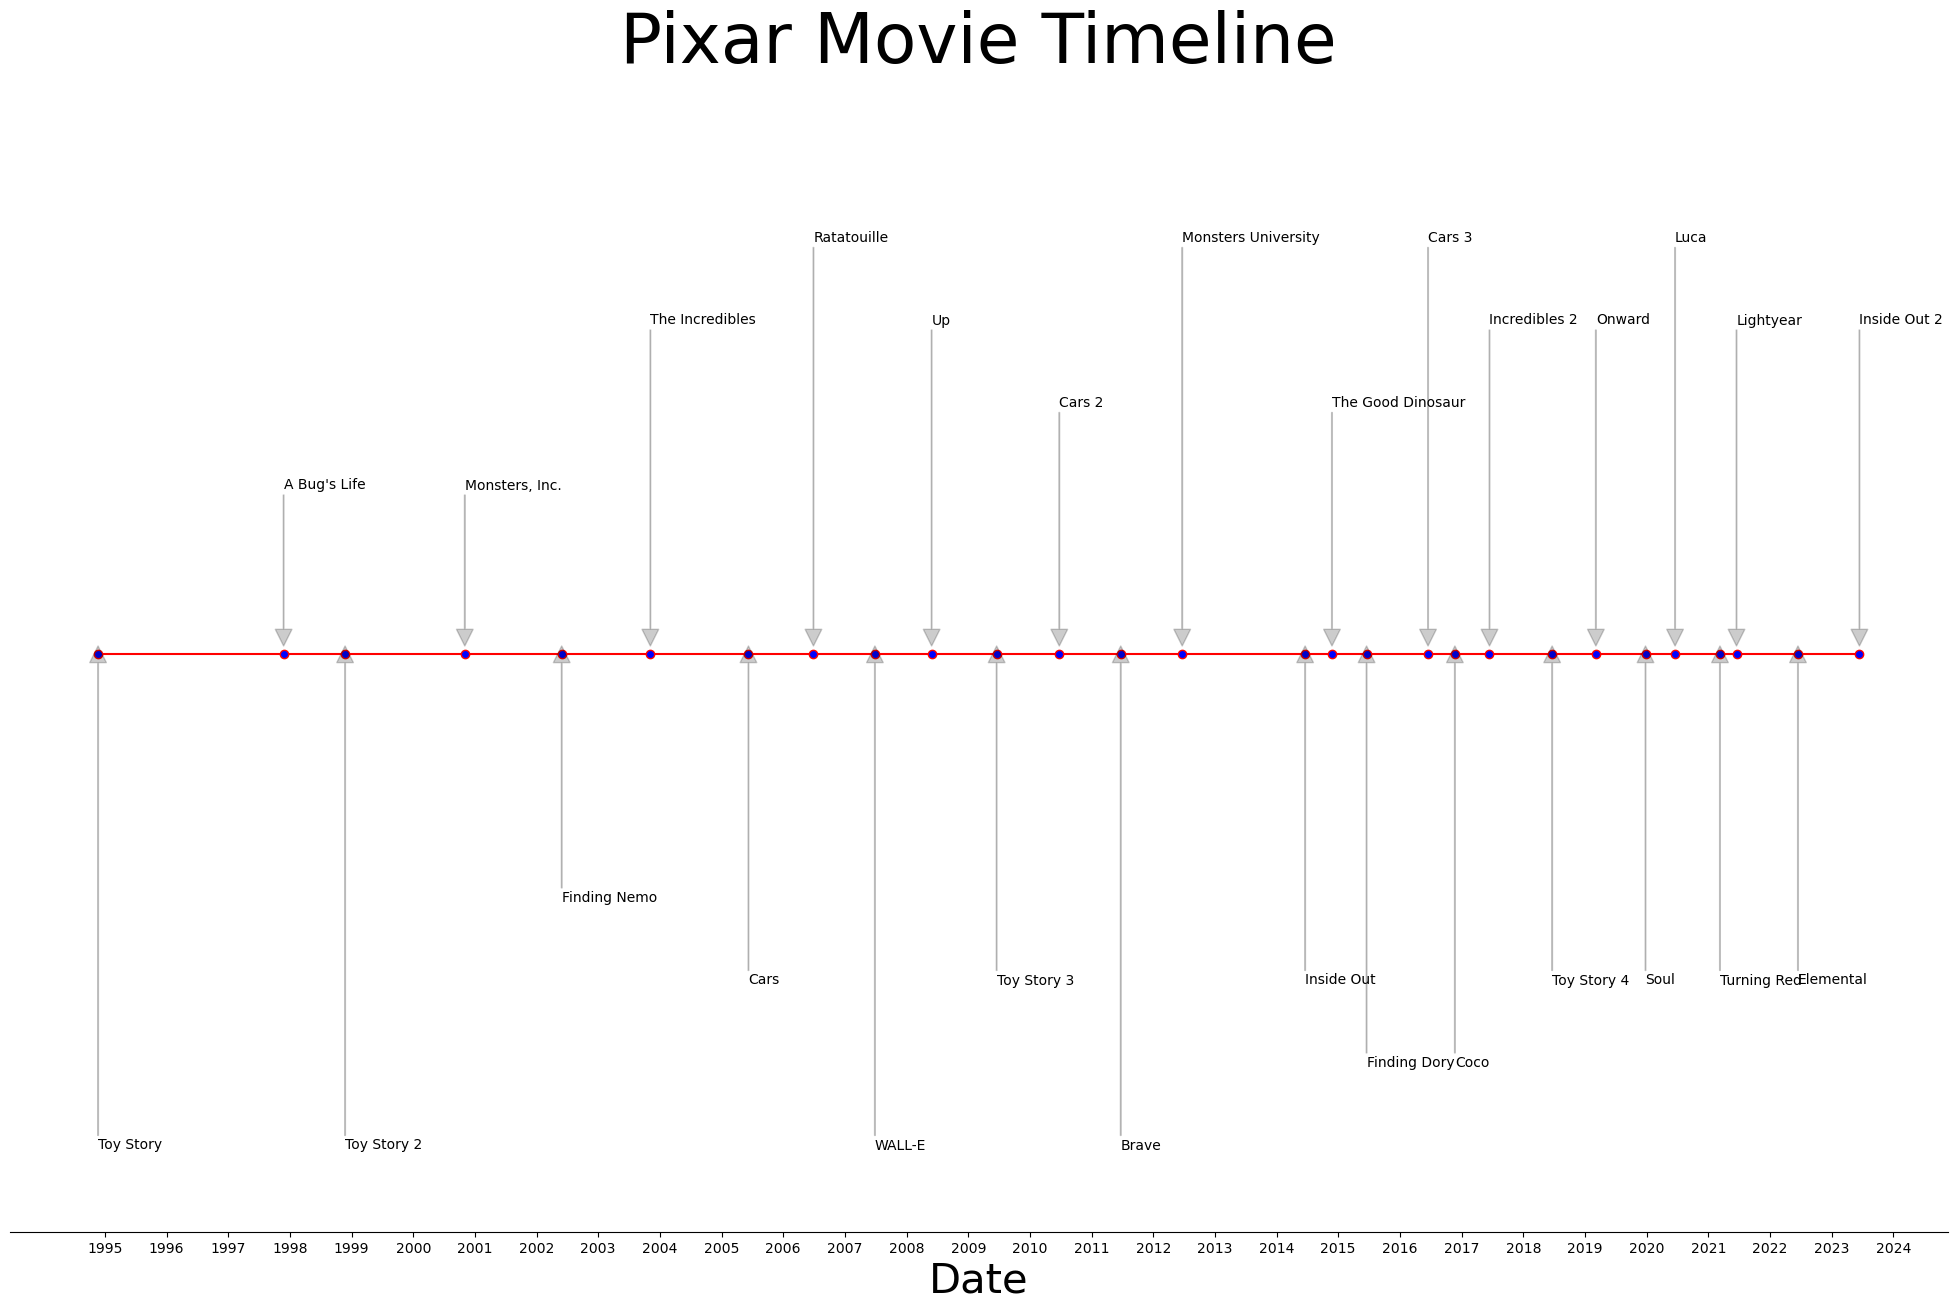

In [14]:
# The following set of code creates the time line

# This line creates the figure for the timeline
fig, ax = plt.subplots(figsize=(25,15))

# This set of code creates the horizontal line for the timeline
ax.plot(pixar_movies.release_date, [0,]* len(pixar_movies), "-o", color="red", markerfacecolor="blue");

# This set of code creates the date range for the timeline
ax.set_xticks(pd.date_range("1995-11-01", "2025-01-01", freq="ys"), range(1995,2025));

ax.set_ylim(-7,7);

# This set of code adds the movies to the time line. In addition the code adds the vertical lines to connect the movies to the dates
for idx in range(len(pixar_movies)):
    film, release_date, level= pixar_movies["film"][idx],pixar_movies["release_date"][idx],pixar_movies["level"][idx]
    ax.annotate(film, xy=(release_date, 0.1), xytext=(release_date, level), 
                arrowprops=dict(color="black", width=0.5, alpha=0.2));

# The final block of code removes the splines and axis. In addition the code creates the title and and label for the date.
ax.spines[["left", "top", "right"]].set_visible(False);
ax.yaxis.set_visible(False);
ax.set_title("Pixar Movie Timeline", size=50)
ax.set_xlabel("Date", size= 30)
plt.show()

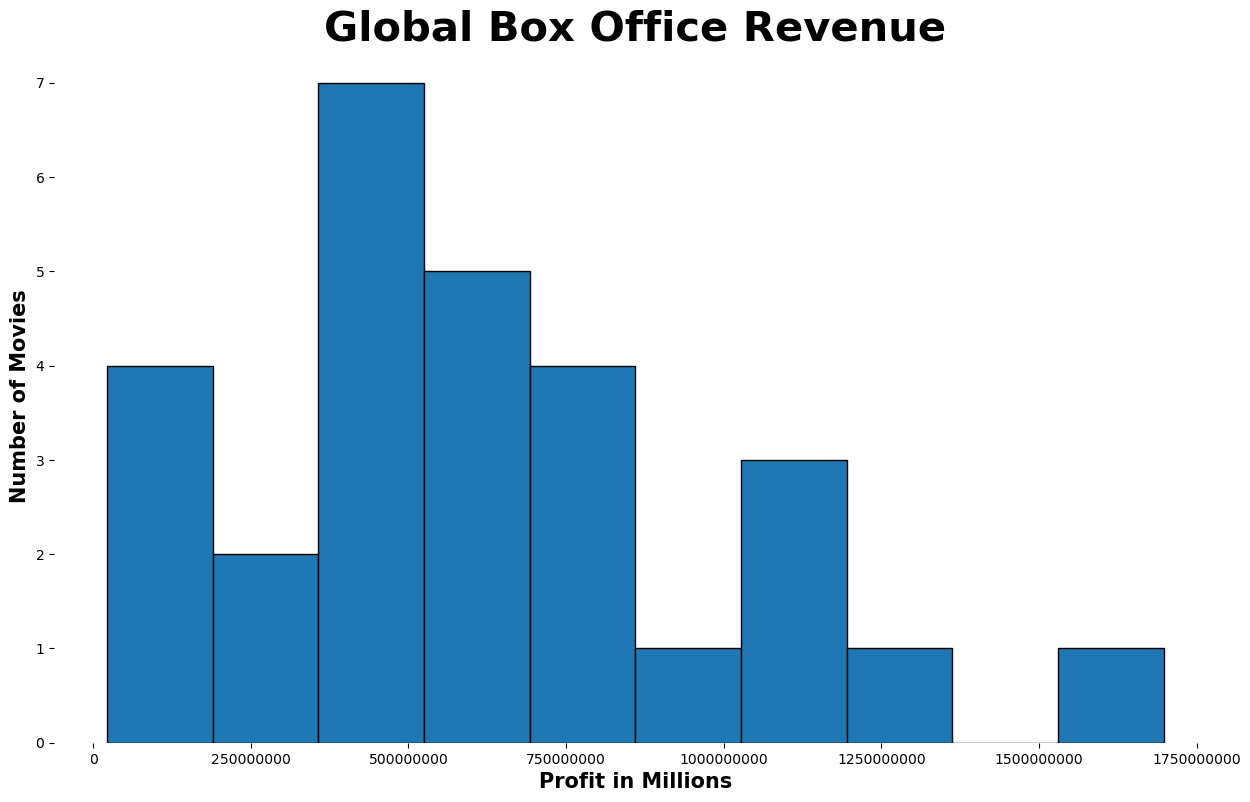

In [15]:
fig, ax = plt.subplots(figsize=(15,9))
plt.title("Global Box Office Revenue", fontsize=30, weight="bold")
plt.xlabel("Profit in Millions", fontsize= 15, weight="bold")
plt.ylabel("Number of Movies", fontsize= 15, weight= "bold")
sns.despine(left= True, top= True, bottom= True)
plt.hist(pixar['box_office_worldwide'], bins=10, edgecolor= "black")
plt.ticklabel_format(style="plain")


plt.show()

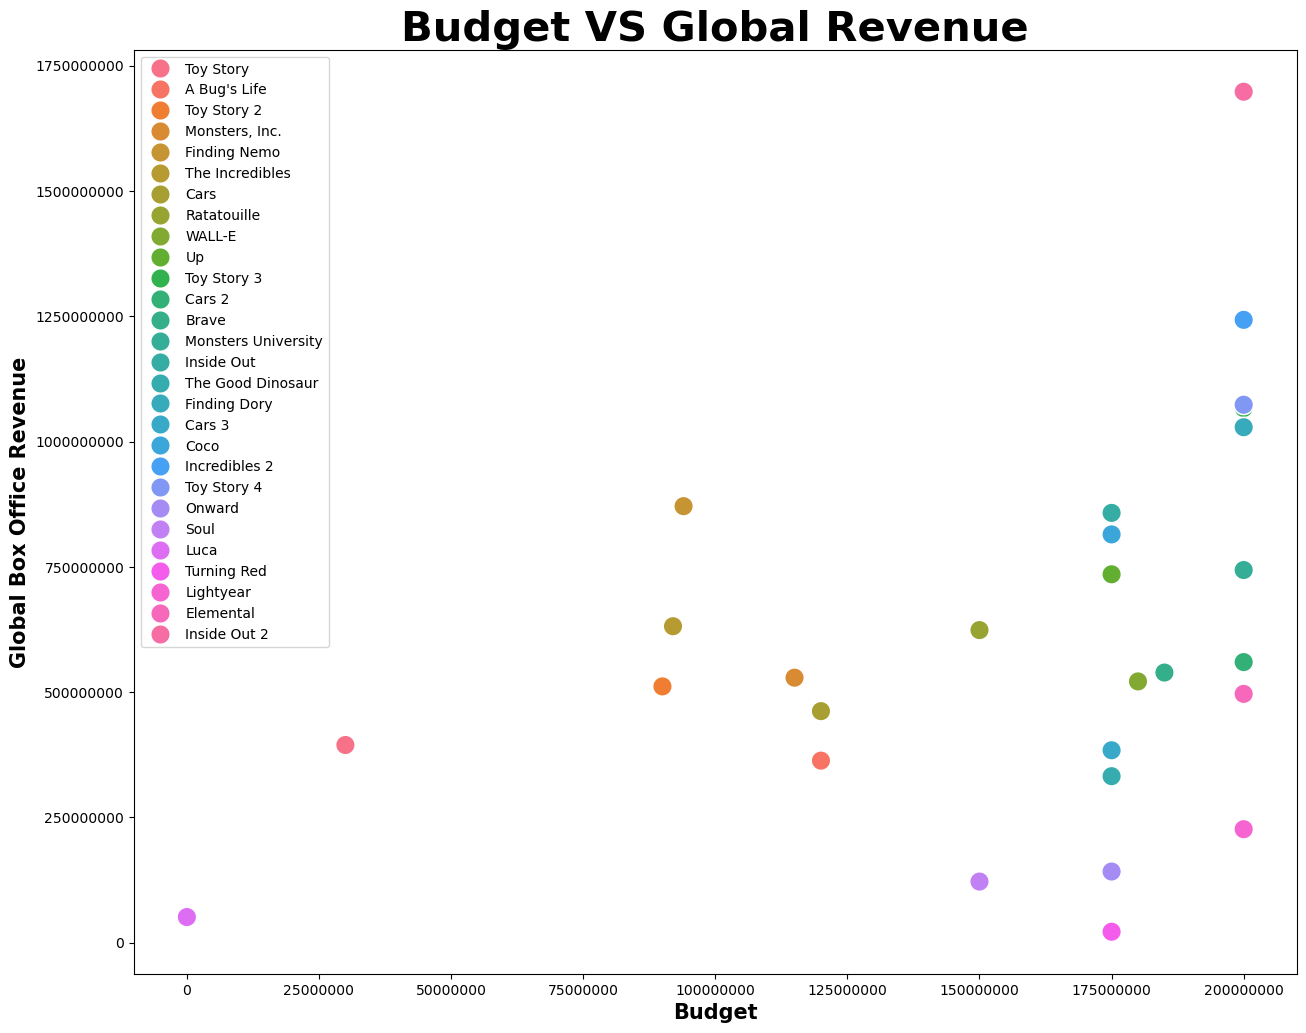

In [16]:
fig, ax = plt.subplots(figsize=(15,12))
sns.scatterplot(x=pixar['budget'], y=pixar['box_office_worldwide'], hue=pixar['film'], s=200)
plt.legend(loc="upper left")
plt.ticklabel_format(style="plain") 
plt.title("Budget VS Global Revenue", fontsize=30, weight="bold")
plt.xlabel("Budget", fontsize=15, weight="bold")
plt.ylabel("Global Box Office Revenue", fontsize=15, weight="bold")
plt.show()

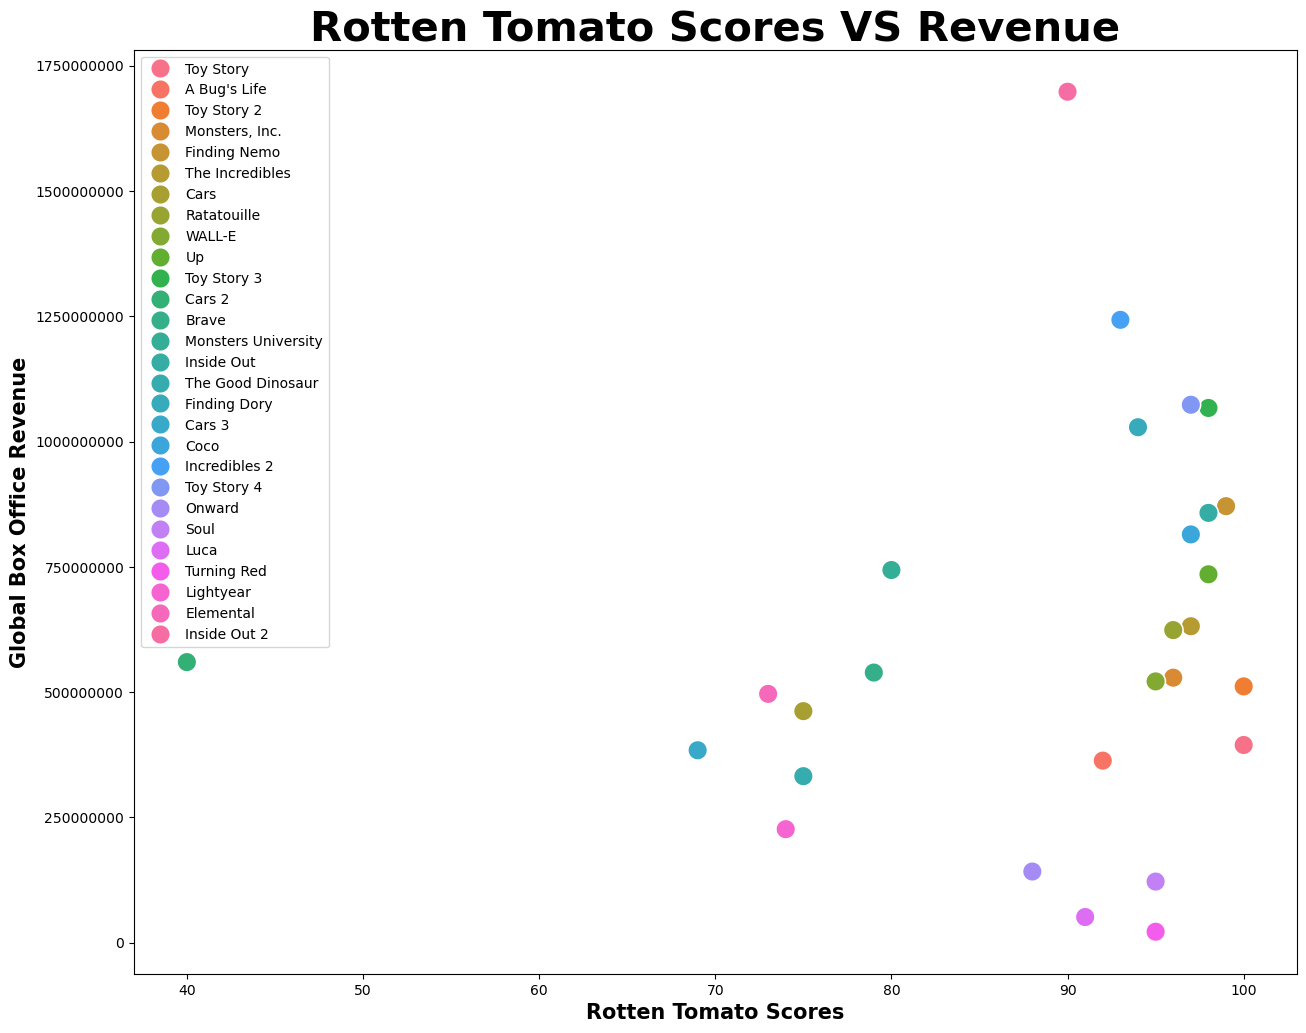

In [17]:
fig, ax = plt.subplots(figsize=(15,12))
sns.scatterplot(x=pixar['rotten_tomatoes_score'], y=pixar['box_office_worldwide'], hue=pixar['film'], s=200)
plt.legend(loc="upper left")
plt.ticklabel_format(style="plain") 
plt.title("Rotten Tomato Scores VS Revenue", fontsize=30, weight="bold")
plt.xlabel("Rotten Tomato Scores", fontsize=15, weight="bold")
plt.ylabel("Global Box Office Revenue", fontsize=15, weight="bold")
plt.show()